<a href="https://colab.research.google.com/github/nishaguptaaa/ds4400project/blob/main/DS_4400_Final_Code_Sunithi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DS4400 Final Project Modeling
## Using Lifestyle and Socioeconomic Factors to Predict Mental Distress
### Authors: Nisha Gupta and Sunithi Krishnan
This notebook contains the final modeling pipeline for our project. It loads the cleaned BRFSS dataset, preprocesses the data, trains four models, evaluates them, and compares their performance.

In [1]:
#imports
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

In [2]:
df = pd.read_csv("data/brfss_small.csv")
df.head()

,_MENT14D,EXERANY2,SMOKE100,SMOKDAY2,ALCDAY4,DRNK3GE5,_BMI5,GENHLTH,PHYSHLTH,INCOME3,EDUCA,EMPLOY1,MARITAL,EMTSUPRT,SDLONELY,_AGE80,_SEX,_RACE
0,1.0,1.0,2.0,NaN,NaN,NaN,2249.0,3.0,2.0,NaN,4.0,NaN,3.0,1.0,5.0,78.0,2.0,1.0
1,1.0,1.0,1.0,3.0,NaN,NaN,2583.0,1.0,NaN,11.0,6.0,NaN,1.0,1.0,5.0,80.0,1.0,1.0
2,1.0,1.0,1.0,1.0,230.0,3.0,2253.0,2.0,30.0,NaN,5.0,1.0,6.0,2.0,5.0,59.0,1.0,1.0
3,1.0,1.0,2.0,NaN,NaN,NaN,2509.0,1.0,NaN,6.0,6.0,NaN,1.0,1.0,5.0,80.0,1.0,1.0
4,1.0,2.0,2.0,NaN,NaN,NaN,1977.0,3.0,NaN,3.0,5.0,NaN,5.0,4.0,1.0,47.0,1.0,1.0


## Preprocessing Data:

In [14]:
#preprocessing
df = pd.read_csv("data/brfss_small.csv")
df = df[df["_MENT14D"].isin([1.0, 2.0])].copy()
df["stress"] = (df["_MENT14D"] == 1).astype(int)

#median imputation for numeric-coded survey variables
df = df.fillna(df.median(numeric_only=True))

print(df.shape)
print("Class distribution:")
print(df["stress"].value_counts())

X = df.drop(columns=["_MENT14D", "stress"])
y = df["stress"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#for models that need scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

(387199, 19)
Class distribution:
stress
1    269909
0    117290
Name: count, dtype: int64


## Logistic Regression Model:

In [16]:
#logistic regression model

log_reg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42)

log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

log_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1": f1_score(y_test, y_pred, zero_division=0),
    "AUC": roc_auc_score(y_test, y_prob)}

print("Logistic Regression Results")
print(pd.DataFrame([log_results]).to_string(index=False))

Logistic Regression Results
              Model  Accuracy  Precision   Recall       F1      AUC
Logistic Regression  0.670829   0.819815 0.676466 0.741274 0.726118


## Random Forest Model

In [17]:
#random forest model

trees = [10, 25, 50, 75, 100, 200]
rf_results = []

for tree in trees:
    rf = RandomForestClassifier(
        n_estimators=tree,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1)

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    y_prob = rf.predict_proba(X_test)[:, 1]

    rf_results.append({
        "Trees": tree,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_test, y_prob)})

results_df_rf = pd.DataFrame(rf_results)
results_df_rf = results_df_rf.sort_values(by=["AUC", "F1"], ascending=False)

print("Random Forest Results:")
print(results_df_rf.to_string(index=False))

Random Forest Results:
 Trees  Accuracy  Precision   Recall       F1      AUC
   200  0.728009   0.762692 0.885258 0.819417 0.724869
   100  0.726317   0.763062 0.880923 0.817768 0.722607
    75  0.725968   0.761941 0.882665 0.817872 0.721241
    50  0.722986   0.764145 0.871642 0.814362 0.718098
    25  0.719783   0.760532 0.872847 0.812828 0.710392
    10  0.700129   0.769465 0.813567 0.790902 0.690915


## Feature Importance:

Top 10 Feature Importances:
 Feature  Importance
   _BMI5    0.237469
  _AGE80    0.197514
 ALCDAY4    0.080114
PHYSHLTH    0.062352
 INCOME3    0.054966
 GENHLTH    0.050109
 MARITAL    0.047578
SDLONELY    0.046716
   EDUCA    0.044428
 EMPLOY1    0.032961


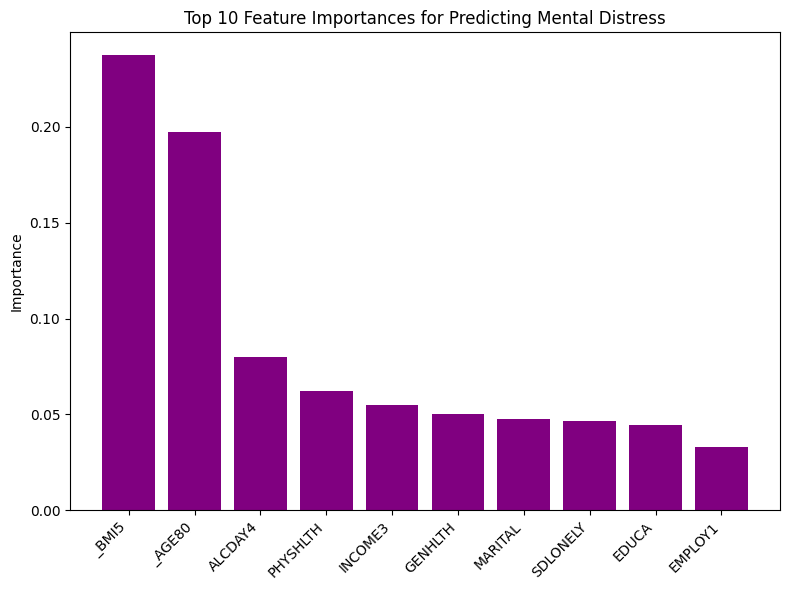

In [19]:
#feature importance

rf_best_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1)

rf_best_model.fit(X_train, y_train)

importances = pd.Series(rf_best_model.feature_importances_, index=X.columns)
importance_df = importances.sort_values(ascending=False).reset_index()
importance_df.columns = ["Feature", "Importance"]

print("Top 10 Feature Importances:")
print(importance_df.head(10).to_string(index=False))

plt.figure(figsize=(8, 6))
plt.bar(importance_df["Feature"].head(10), importance_df["Importance"].head(10), color="purple")
plt.title("Top 10 Feature Importances for Predicting Mental Distress")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Gradient Boosting Model:

In [20]:
#gradient boosting model

estimators = [10, 25, 50, 75, 100, 200]
gb_results = []

for estimator in estimators:
    gb = GradientBoostingClassifier(
        n_estimators=estimator,
        learning_rate=0.1,
        random_state=42)

    gb.fit(X_train, y_train)

    y_pred = gb.predict(X_test)
    y_prob = gb.predict_proba(X_test)[:, 1]

    gb_results.append({
        "Trees": estimator,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_test, y_prob)})

results_df_gb = pd.DataFrame(gb_results)
results_df_gb = results_df_gb.sort_values(by=["AUC", "F1"], ascending=False)

print("Gradient Boosting Results")
print(results_df_gb.to_string(index=False))

Gradient Boosting Results
 Trees  Accuracy  Precision   Recall       F1      AUC
   200  0.746320   0.766886 0.913879 0.833955 0.757934
   100  0.744357   0.762070 0.920733 0.833922 0.755651
    75  0.743143   0.758559 0.926383 0.834113 0.754467
    50  0.740315   0.751590 0.937238 0.834210 0.751597
    25  0.730811   0.734714 0.960728 0.832656 0.744316
    10  0.712668   0.711627 0.988292 0.827446 0.728938


## Neural Network Model

In [21]:
#neural network model

nn = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=300,
    random_state=42)

nn.fit(X_train_scaled, y_train)

y_pred = nn.predict(X_test_scaled)
y_prob = nn.predict_proba(X_test_scaled)[:, 1]

nn_results = {
    "Model": "Neural Network",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1": f1_score(y_test, y_pred, zero_division=0),
    "AUC": roc_auc_score(y_test, y_prob)}

print("Neural Network Results")
print(pd.DataFrame([nn_results]).to_string(index=False))

Neural Network Results
         Model  Accuracy  Precision   Recall      F1      AUC
Neural Network  0.740664   0.773419 0.888166 0.82683 0.751589


## Model Comparison:

In [22]:
#comparing models

rf_best = results_df_rf.iloc[0]
gb_best = results_df_gb.iloc[0]

comparison_df = pd.DataFrame([
    log_results,
    {
        "Model": "Random Forest",
        "Accuracy": rf_best["Accuracy"],
        "Precision": rf_best["Precision"],
        "Recall": rf_best["Recall"],
        "F1": rf_best["F1"],
        "AUC": rf_best["AUC"]},
    {
        "Model": "Gradient Boosting",
        "Accuracy": gb_best["Accuracy"],
        "Precision": gb_best["Precision"],
        "Recall": gb_best["Recall"],
        "F1": gb_best["F1"],
        "AUC": gb_best["AUC"]},
    nn_results])

print(comparison_df.to_string(index=False))

              Model  Accuracy  Precision   Recall       F1      AUC
Logistic Regression  0.670829   0.819815 0.676466 0.741274 0.726118
      Random Forest  0.728009   0.762692 0.885258 0.819417 0.724869
  Gradient Boosting  0.746320   0.766886 0.913879 0.833955 0.757934
     Neural Network  0.740664   0.773419 0.888166 0.826830 0.751589
